<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>


# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [3]:
import pandas as pd# importar librerías

In [4]:
df_orders=pd.read_csv('/datasets/instacart_orders.csv',sep=';') 
df_products=pd.read_csv('/datasets/products.csv',sep=';')
df_aisles=pd.read_csv('/datasets/aisles.csv',sep=';')
df_departments=pd.read_csv('/datasets/departments.csv',sep=';')
df_order_products=pd.read_csv('/datasets/order_products.csv',sep=';')

In [5]:
df_orders.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [6]:
df_products.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [7]:
df_aisles.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [8]:
df_departments.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [9]:
df_order_products.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Buena manera de leer los datos y buenas observaciones iniciales.<br/>
    
La razón del porque no te aparecen todos los valores del dataframe `df_order_products` es porque es contiene mucha información y pandas trata de optimizar esto al no mostrar los resultados, pero le podemos indicar que lo haga de cualquier manera utilizando el siguiente argumento:
    
```
df_order_products.info(show_counts=True)    
```    
</div>


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.


El DF orders tiene 6 columnas, estan separadas por ; , la columna days_since_prior_order tiene datos faltantes, y el contenido es numerico en todas las columnas.
En el DF products, hay 4 columnas, , la columna product_name tambien tiene datos faltantes y el tipo de dato es categorico, las demas son numericas y estan completas, 
En el DF aisles, hay 2 columnas, completas, y la columna aisle es de tipo categorico, mientras que aisle_id es numerico.
El DF order_products tiene 4 columnas, de tipo numerico, (no se por que no me sale si hay valores no nulos)
En el DF departments, hay dos columnas, completas una columa es numerica y la otra categorica

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

Verificar los datos, buscar los valores ausentes que sé que hay en algunas columnas,usnado el metodo isna(), tambien  es necesario rellenar estos datos, para hacerlo buscar si ahy algun patron que me indique por que estan ausentes y cuales son  

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [12]:
df_orders.duplicated().sum()# Revisa si hay pedidos duplicados


15

In [13]:
duplicated_rows = df_orders[df_orders.duplicated()]
print(duplicated_rows)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

Hay 15 lineas duplicadas, y al pareces todas corresponden al mismo dia de la semana que se hizo el pedido y la misma hora

In [15]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
miercoles_2am = df_orders[(df_orders['order_dow']==3) & (df_orders['order_hour_of_day']==2)]
print(len(miercoles_2am))


121


¿Qué sugiere este resultado?

In [23]:
Teniendo en cuenta que hay 15 pedidos duplicados, se inferiria que en total hay 106 pedidos unicos el miercoles a las 2 am

SyntaxError: invalid syntax (2974866213.py, line 1)

In [16]:
# Elimina los pedidos duplicados
df_orders_clean = df_orders.drop_duplicates()
print(df_orders_clean)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
0        1515936   183418            11          6                 13   
1        1690866   163593             5          5                 12   
2        1454967    39980             4          5                 19   
3        1768857    82516            56          0                 20   
4        3007858   196724             2          4                 12   
...          ...      ...           ...        ...                ...   
478962   3210681     5617             5          1                 14   
478963   3270802   112087             2          3                 13   
478964    885349    82944            16          2                 11   
478965    216274     4391             3          3                  8   
478966   2071924     1730            18          1                 14   

        days_since_prior_order  
0                         30.0  
1                          9.0  
2                       

In [17]:
df_orders_clean.duplicated().sum()# Vuelve a verificar si hay filas duplicadas


0

In [18]:
df_orders_clean['order_id'].duplicated().sum()# Vuelve a verificar únicamente si hay IDs duplicados de pedidos


0

Describe brevemente tus hallazgos y lo que hiciste con ellos

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Los duplicados fueron eliminados correctamente
</div>


### `products` data frame

In [19]:
df_products.duplicated().sum()# Verifica si hay filas totalmente duplicadas


0

In [20]:
df_products['product_id'].duplicated().sum()# Revisa únicamente si hay ID de productos duplicados


0

In [21]:
df_products['product_name'].str.upper().duplicated().sum()# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)


1361

In [22]:
df_products['product_name'].dropna().str.upper().duplicated().sum()# Revisa si hay nombres duplicados de productos no faltantes


104

Describe brevemente tus hallazgos y lo que hiciste con ellos.

In [31]:
Al parecer hay 104 productos con nombre igual lo  ucal indicaria que hay un problema con su nomenclatura , seria importante verificar si el id del producto es el mismo

SyntaxError: invalid syntax (2936184647.py, line 1)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Los datos han sido revisados apropiadamente
</div>


### `departments` data frame

In [23]:
df_departments.duplicated().sum()# Revisa si hay filas totalmente duplicadas

0

In [24]:
df_departments['department_id'].duplicated().sum()# Revisa únicamente si hay IDs duplicadas de departamentos

0

Describe brevemente tus hallazgos y lo que hiciste con ellos.

No hay filas duplicadas en el DF de departamentos ni id duplicados

### `aisles` data frame

In [26]:
df_aisles.duplicated().sum()# Revisa si hay filas totalmente duplicadas

0

In [27]:
df_aisles['aisle_id'].duplicated().sum()# Revisa únicamente si hay IDs duplicadas de pasillos

0

Describe brevemente tus hallazgos y lo que hiciste con ellos.

In [37]:
No hay filas en el DF de aisles duplicadas tampoco id de los pasillos duplicados

SyntaxError: invalid syntax (24768518.py, line 1)

### `order_products` data frame

In [28]:
df_order_products.duplicated().sum()# Revisa si hay filas totalmente duplicadas


0

In [29]:
valores_faltantes = df_order_products['add_to_cart_order'].isna().sum()# Vuelve a verificar si hay cualquier otro duplicado engañoso
print(valores_faltantes)

836


Describe brevemente tus hallazgos y lo que hiciste con ellos.

In [40]:
Hay 836 valroes faltantes en la columan add_to_cart_order

SyntaxError: invalid syntax (2781129414.py, line 1)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Estos últimos dataframes no cuentan con filas totalmente duplicadas.

</div>


## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [30]:
nombres_ausentes= df_products[df_products['product_name'].isna()]
print(nombres_ausentes)# Encuentra los valores ausentes en la columna 'product_name'

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos.

In [31]:
nombres_ausentes['aisle_id'].unique()#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?


array([100])

Describe brevemente cuáles son tus hallazgos.

Los 1258 productos ausentes corresponden al pasillo con ID 100

In [33]:
nombres_ausentes['department_id'].unique()# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?


array([21])

Describe brevemente cuáles son tus hallazgos.

In [45]:
los productos ausentes tambien corrensponden con el departamento de ID 21. Todos los productos con nombre ausente vienen del pasillo 100 y el departamento 21

SyntaxError: invalid syntax (3827405510.py, line 1)

In [34]:
print(df_aisles[df_aisles['aisle_id'] == 100])
print(df_departments[df_departments['department_id']==21])

    aisle_id    aisle
99       100  missing
    department_id department
20             21    missing


Describe brevemente cuáles son tus hallazgos.

In [47]:
los productos del pasillo 100 y el departamento 21 tienen nombre missing, es decir estan ausentes

SyntaxError: invalid syntax (1710143857.py, line 1)

In [35]:
# Completa los nombres de productos ausentes con 'Unknown'
df_products['product_name'] = df_products['product_name'].fillna('Unknown')
no_name_products = df_products['product_name'].isna().sum()
print(no_name_products)


0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
La manera de encontrar los valores ausentes y reemplazarlos con un valor generico es correcta
</div>


### `orders` data frame

In [36]:
ordenes_ausentes = df_orders_clean[df_orders_clean['days_since_prior_order'].isna()]
print(ordenes_ausentes)# Encuentra los valores ausentes

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

In [37]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `order_products` data frame

In [38]:
ordenes_de_producto_ausentes = df_order_products[df_order_products['add_to_cart_order'].isna()]
print(ordenes_de_producto_ausentes)# Encuentra los valores ausentes

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [39]:
print(df_order_products['add_to_cart_order'].describe())
print("Valor mínimo:", df_order_products['add_to_cart_order'].min())
print("Valor máximo:", df_order_products['add_to_cart_order'].max())


count    4.544171e+06
mean     8.351669e+00
std      7.080368e+00
min      1.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.100000e+01
max      6.400000e+01
Name: add_to_cart_order, dtype: float64
Valor mínimo: 1.0
Valor máximo: 64.0


Describe brevemente cuáles son tus hallazgos.

In [53]:
El valor minimo es 1 y el maximo es 64

SyntaxError: invalid syntax (3424331040.py, line 1)

In [40]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
missing_order_ids = df_order_products[df_order_products['add_to_cart_order'].isna()]['order_id'].unique()
print(missing_order_ids)

[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [41]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
print(len(missing_order_ids))
missing_add_to_cart = df_order_products[df_order_products['add_to_cart_order'].isna()]
missing_grouped = missing_add_to_cart.groupby('order_id').size()
print(missing_grouped)
print(min(missing_grouped))
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.


70
order_id
9310        1
61355      63
102236     31
129627      5
165801      6
           ..
2999801     6
3125735    22
3308010    51
3347453     7
3383594     5
Length: 70, dtype: int64
1


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Cuidado!<br/>
    
El valor minimo para ordenes que tienen valores nulos es `65`, te dejo el código en la celda de abajo
</div>


In [42]:
# Código del revisor
df_order_products[df_order_products['order_id'].isin(missing_order_ids)].groupby('order_id')['product_id'].count().min()

65

Describe brevemente cuáles son tus hallazgos.

In [43]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
df_order_products['add_to_cart_order'] = (
    df_order_products['add_to_cart_order']
    .fillna(999)
    .astype(int)
)
print(df_order_products)

         order_id  product_id  add_to_cart_order  reordered
0         2141543       11440                 17          0
1          567889        1560                  1          1
2         2261212       26683                  1          1
3          491251        8670                 35          1
4         2571142        1940                  5          1
...           ...         ...                ...        ...
4545002    577211       15290                 12          1
4545003   1219554       21914                  9          0
4545004    692640       47766                  4          1
4545005    319435         691                  8          1
4545006   1398151       28733                  9          0

[4545007 rows x 4 columns]


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
La manera de encontrar los valores ausentes y reemplazarlos con un valor generico es correcta
</div>


Describe brevemente tus hallazgos y lo que hiciste con ellos.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [44]:
print(sorted(df_orders_clean['order_hour_of_day'].unique()))
print(sorted(df_orders_clean['order_dow'].unique()))


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
[0, 1, 2, 3, 4, 5, 6]


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Se verificó que los datos sean sensibles correctamente
</div>


order_hour_of_day
0      2991
1      1671
2       958
3       744
4       735
5      1281
6      3757
7     10993
8     20268
9     28112
10    32195
11    32660
12    31754
13    32433
14    32797
15    32894
16    31579
17    26825
18    21795
19    17026
20    12891
21     9806
22     7670
23     5167
Name: user_id, dtype: int64


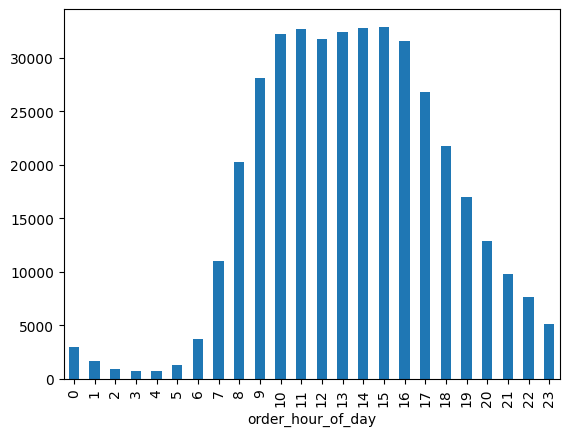

In [46]:
import matplotlib.pyplot as plt
personas_por_hora = df_orders_clean.groupby('order_hour_of_day')['user_id'].nunique()
print(personas_por_hora)
personas_por_hora.plot(kind='bar')
plt.show()

order_dow
0    57661
1    56479
2    48587
3    45331
4    44281
5    46127
6    45604
Name: user_id, dtype: int64


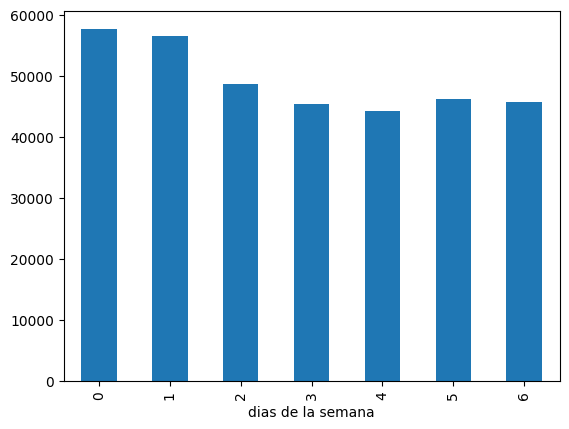

In [47]:
import matplotlib.pyplot as plt
personas_por_dia = df_orders_clean.groupby('order_dow')['user_id'].nunique()
print(personas_por_dia)
personas_por_dia.plot(kind='bar', xlabel= 'dias de la semana')
plt.show()

days_since_prior_order
0.0      7532
1.0     13286
2.0     17552
3.0     20426
4.0     22347
5.0     23330
6.0     26812
7.0     32021
8.0     21772
9.0     15354
10.0    12412
11.0    10847
12.0    10177
13.0    11172
14.0    13080
15.0     9044
16.0     6411
17.0     5368
18.0     4896
19.0     4835
20.0     5187
21.0     6276
22.0     4439
23.0     3285
24.0     2974
25.0     2690
26.0     2620
27.0     2961
28.0     3684
29.0     2647
30.0    44444
Name: user_id, dtype: int64


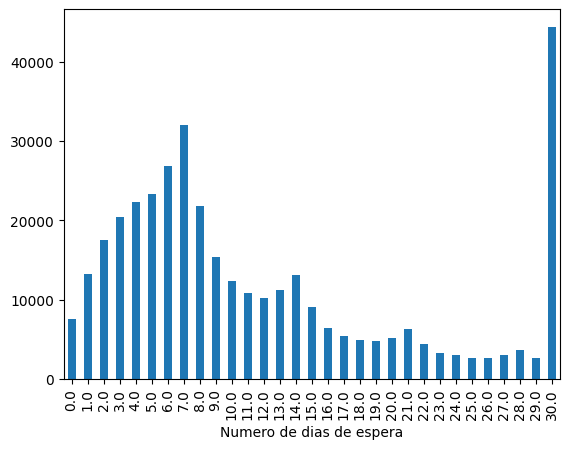

In [48]:
import matplotlib.pyplot as plt
tiempo_de_espera = df_orders_clean.groupby('days_since_prior_order')['user_id'].nunique()
print(tiempo_de_espera)
tiempo_de_espera.plot(kind='bar', xlabel= 'Numero de dias de espera')
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Las gráficas anteriores tienen su propias secciones para ser mostradas
</div>


Escribe aquí tus conclusiones

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

A las 12 am 2991 hacen compras,1am 1671 2       958 3       744
4       735
5      1281
6      3757
7     10993
8     20268
9     28112
10    32195
11    32660
12    31754
13    32433
14    32797
15    32894
16    31579
17    26825
18    21795
19    17026
20    12891
21     9806
22     7670
23     5167

Escribe aquí tus conclusiones

### [A3] ¿Qué día de la semana compran víveres las personas?

In [62]:
Todos los dias laspersona compran viveres

SyntaxError: invalid syntax (3743739951.py, line 1)

Escribe aquí tus conclusiones

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

In [63]:
print( df_orders_clean['days_since_prior_order'].max())
print( df_orders_clean['days_since_prior_order'].min())
print( df_orders_clean['days_since_prior_order'].mean())

30.0
0.0
11.101813900274362


In [64]:
en promedio las personas esperan 11 dias para hacer otro pedido, tambien hay personas que no esperan otro dia o hasta 30 dias esperan para comprar nuevamente

SyntaxError: invalid syntax (2935763179.py, line 1)

Escribe aquí tus conclusiones

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [50]:
wednesday = df_orders_clean[df_orders_clean['order_dow'] == 3]
saturday = df_orders_clean[df_orders_clean['order_dow'] == 6]
orders_wed = wednesday.groupby('order_hour_of_day')['order_id'].count()
orders_sat = saturday.groupby('order_hour_of_day')['order_id'].count()
print(orders_wed)
print(orders_sat)

order_hour_of_day
0      373
1      215
2      106
3      101
4      108
5      170
6      643
7     1732
8     3125
9     4490
10    5026
11    5004
12    4688
13    4674
14    4774
15    5163
16    4976
17    4175
18    3463
19    2652
20    1917
21    1450
22    1154
23     718
Name: order_id, dtype: int64
order_hour_of_day
0      464
1      254
2      177
3      125
4      118
5      161
6      451
7     1619
8     3246
9     4311
10    4919
11    5116
12    5132
13    5323
14    5375
15    5188
16    5029
17    4295
18    3338
19    2610
20    1847
21    1473
22    1185
23     893
Name: order_id, dtype: int64


In [51]:
distribucion_wed_sat=pd.concat([orders_wed,orders_sat],axis=1)
print(distribucion_wed_sat)

                   order_id  order_id
order_hour_of_day                    
0                       373       464
1                       215       254
2                       106       177
3                       101       125
4                       108       118
5                       170       161
6                       643       451
7                      1732      1619
8                      3125      3246
9                      4490      4311
10                     5026      4919
11                     5004      5116
12                     4688      5132
13                     4674      5323
14                     4774      5375
15                     5163      5188
16                     4976      5029
17                     4175      4295
18                     3463      3338
19                     2652      2610
20                     1917      1847
21                     1450      1473
22                     1154      1185
23                      718       893


<AxesSubplot:xlabel='order_hour_of_day'>

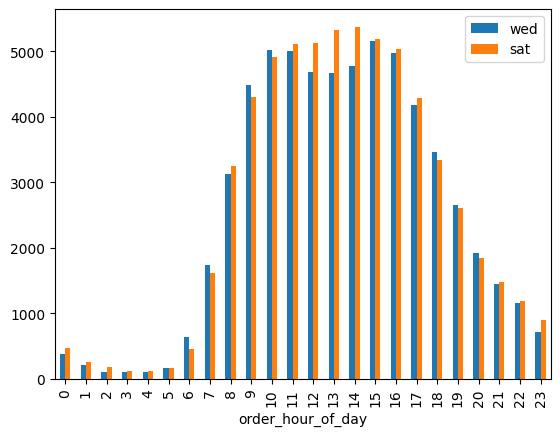

In [52]:
distribucion_wed_sat.columns=['wed','sat']
distribucion_wed_sat.plot(kind='bar')

In [68]:
Si hay diferencias entre la distribución de ordenes por hora del dia entre miercoles y sabado, el miercoles presenta dos picos , uno entre 10 y 11 de la manana y otro entre 3 y 4 de la tarde , mientras que el sabado el pico se da entre 1 y 2 de la tarde , tambien se observa que el miercoles las persons compran mas por la mañana y el sabado lo hacen mas en la tarde.


SyntaxError: invalid syntax (224285073.py, line 1)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!
<br />
Buena manera de mostrar los resultados de ambos días en una misma grafica
</div>


Escribe aquí tus conclusiones

In [53]:
orders_per_user = df_orders_clean.groupby('user_id')['order_id'].nunique()
print(orders_per_user)

user_id
2         2
4         2
5         1
6         2
7         2
         ..
206203    1
206206    7
206207    5
206208    9
206209    2
Name: order_id, Length: 157437, dtype: int64


### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

<AxesSubplot:>

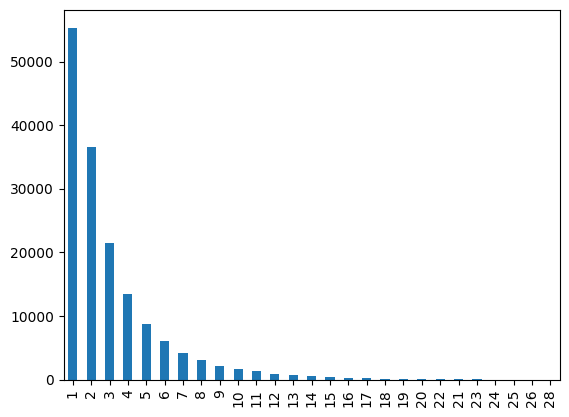

In [54]:
orders_per_user.value_counts().plot(kind='bar')

In [ ]:
La mayoria de clientes solo hicieron un pedido, y va disminuyendo exponencialmente

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/> 

La mayoría de usuarios no ha hecho muchos pedidos, buenas observaciones.

</div>


Escribe aquí tus conclusiones

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [55]:
df_merged = df_order_products.merge(df_products, on='product_id', how='left')
print(df_merged)

         order_id  product_id  add_to_cart_order  reordered  \
0         2141543       11440                 17          0   
1          567889        1560                  1          1   
2         2261212       26683                  1          1   
3          491251        8670                 35          1   
4         2571142        1940                  5          1   
...           ...         ...                ...        ...   
4545002    577211       15290                 12          1   
4545003   1219554       21914                  9          0   
4545004    692640       47766                  4          1   
4545005    319435         691                  8          1   
4545006   1398151       28733                  9          0   

                                              product_name  aisle_id  \
0                           Chicken Breast Tenders Breaded       129   
1                                               Bag Of Ice        37   
2        Cafe Latte Pure Li

In [56]:
product_counts = (
    df_merged['product_name']
    .value_counts().head())
print(product_counts)

Banana                    66050
Bag of Organic Bananas    53297
Organic Strawberries      37039
Organic Baby Spinach      33971
Organic Hass Avocado      29773
Name: product_name, dtype: int64


In [57]:
top_products = (
    df_merged.groupby(['product_id', 'product_name'])
    .size()
    .reset_index(name='order_count')
    .sort_values(by='order_count', ascending=False)
    .head(20)
)
print(top_products)

       product_id              product_name  order_count
22808       24852                    Banana        66050
12025       13176    Bag of Organic Bananas        53297
19370       21137      Organic Strawberries        37039
20077       21903      Organic Baby Spinach        33971
43271       47209      Organic Hass Avocado        29773
43788       47766           Organic Avocado        24689
43663       47626               Large Lemon        21495
15364       16797              Strawberries        20018
24047       26209                     Limes        19690
25556       27845        Organic Whole Milk        19600
25666       27966       Organic Raspberries        19197
21025       22935      Organic Yellow Onion        15898
22908       24964            Organic Garlic        15292
41244       45007          Organic Zucchini        14584
35996       39275       Organic Blueberries        13879
45561       49683            Cucumber Kirby        13675
25889       28204        Organi

Escribe aquí tus conclusiones

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Los resultados son acertados!<br/>
Los clientes tienden a comprar productos naturales, buena manera de mostrar los resultados
</div>


In [ ]:
Los productos que mas se compran son frutas y verduras, la mas pedida es el banano.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [58]:
items_per_order = df_order_products.groupby('order_id')['product_id'].count()

In [59]:
print(items_per_order.describe())

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: product_id, dtype: float64


<AxesSubplot:ylabel='Frequency'>

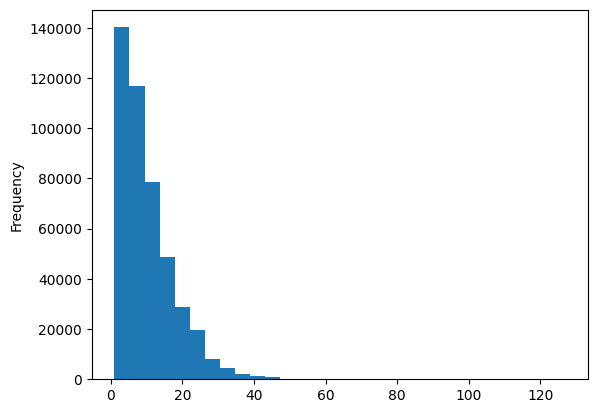

In [60]:
items_per_order.plot(kind='hist',bins=30)

Escribe aquí tus conclusiones

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho, el resultado es correcto, los usuarios suelen pedir alrededor de 10 articulos
</div>


In [ ]:
la mayoria de pedidos tienen entre 5 y 10 articulos

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [61]:
reordered_counts = df_order_products.groupby('product_id')['reordered'].sum().reset_index()
print(reordered_counts)

       product_id  reordered
0               1        158
1               2          0
2               3         31
3               4         25
4               7          1
...           ...        ...
45568       49690          4
45569       49691         31
45570       49692          5
45571       49693         11
45572       49694          3

[45573 rows x 2 columns]


In [62]:
top_reordered = reordered_counts.sort_values('reordered', ascending=False).head(20)
top_reordered = top_reordered.merge(df_products[['product_id', 'product_name']], on='product_id', how='left')

In [63]:
top_reordered[['product_id', 'product_name', 'reordered']]

,product_id,product_name,reordered
0,24852,Banana,55763
1,13176,Bag of Organic Bananas,44450
2,21137,Organic Strawberries,28639
3,21903,Organic Baby Spinach,26233
4,47209,Organic Hass Avocado,23629
5,47766,Organic Avocado,18743
6,27845,Organic Whole Milk,16251
7,47626,Large Lemon,15044
8,27966,Organic Raspberries,14748
9,16797,Strawberries,13945


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/> 
Buena manera de mostrar los resultados, los productos naturales son consistentemente los más vendidos
</div>


In [ ]:
los productos que mas se reordenaron tambien son las bananas

Escribe aquí tus conclusiones

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [64]:
reorder_ratio = df_order_products.groupby('product_id')['reordered'].mean().reset_index()
reorder_ratio.columns = ['product_id', 'reorder_ratio']
print(reorder_ratio)

       product_id  reorder_ratio
0               1       0.564286
1               2       0.000000
2               3       0.738095
3               4       0.510204
4               7       0.500000
...           ...            ...
45568       49690       0.800000
45569       49691       0.430556
45570       49692       0.416667
45571       49693       0.440000
45572       49694       0.333333

[45573 rows x 2 columns]


Escribe aquí tus conclusiones

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [65]:
df_merged = df_order_products.merge(df_orders[['order_id', 'user_id']], on='order_id', how='left')

In [66]:
reorder_ratio_user = df_merged.groupby('user_id')['reordered'].mean().reset_index()
reorder_ratio_user.columns = ['user_id', 'reorder_ratio']
print(reorder_ratio_user)

        user_id  reorder_ratio
0             2       0.038462
1             4       0.000000
2             5       0.666667
3             6       0.000000
4             7       0.928571
...         ...            ...
149621   206203       0.222222
149622   206206       0.714286
149623   206207       0.891304
149624   206208       0.696000
149625   206209       0.320000

[149626 rows x 2 columns]


Escribe aquí tus conclusiones

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Buena manera de realizar las proporciones
</div>


### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [67]:
first_in_cart = df_order_products[df_order_products['add_to_cart_order'] == 1]

In [68]:
first_counts = first_in_cart['product_id'].value_counts().reset_index()
first_counts.columns = ['product_id', 'first_count']
print(first_counts)

       product_id  first_count
0           24852        15562
1           13176        11026
2           27845         4363
3           21137         3946
4           47209         3390
...           ...          ...
26755       10628            1
26756        8581            1
26757       35216            1
26758       43412            1
26759        4094            1

[26760 rows x 2 columns]


In [69]:
first_counts = first_counts.merge(df_products[['product_id', 'product_name']], on='product_id', how='left')
print(first_counts.head(20))

    product_id  first_count                 product_name
0        24852        15562                       Banana
1        13176        11026       Bag of Organic Bananas
2        27845         4363           Organic Whole Milk
3        21137         3946         Organic Strawberries
4        47209         3390         Organic Hass Avocado
5        21903         3336         Organic Baby Spinach
6        47766         3044              Organic Avocado
7        19660         2336                 Spring Water
8        16797         2308                 Strawberries
9        27966         2024          Organic Raspberries
10       44632         1914   Sparkling Water Grapefruit
11       49235         1797          Organic Half & Half
12       47626         1737                  Large Lemon
13         196         1733                         Soda
14       38689         1397     Organic Reduced Fat Milk
15       26209         1370                        Limes
16       12341         1340    

Escribe aquí tus conclusiones


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Una vez más los productos orgánicos estan en el top de la lista<br/>
</div>


In [ ]:
Los productos que más frecuentemente se agregan primero al carrito tambien coinciden con los que se reordenan, suelen ser por ejemplo, leche, banano, huevos. Esto puede reflejar que los usuarios comienzan sus compras con productos rutinarios

### Conclusion general del proyecto:

In [ ]:
En geeralla mayoria de personas haen sus pedidos entre las 9am y 5pm, los dias que mas compran son los domingos y lunes, la mayoria espera mas de 30 dias para reordenar aunque tambien se observa que a los 7 dias tambien hay un pico de personas que vuelven a pedir, el sabado las persona compran viveres alrededor del medio dia, mientras que los miercoleslo hacen a mitad de la manana y mitad de la tarde, la mayoria de clientes hace un pedido al mes, y los productos mas populares son frutas y verduras, tambien leche, ya que son los mas pedidos, los mas reordenados y los que primero eligen en su cansta de compras

In [ ]:
Nota: fue muy dificil hacerlo, y por tiempo use mucho la ayuda de dot :(

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, los procedimientos realizados son correctos. Considero que este es un proyecto que se empieza a asemejar más a algún proyecto que te pidan en un trabajo, a partir de análisis de este tipo se pueden diseñar estrategias de marketing específicas para ciertos productos o se pueden optimizar los procesos internos para tener disponibles más rápidamente los productos que se venden más seguido.<br/>
    

Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen bastante detalladas
- Las graficas utilizadas me parecen del tipo correcto

    
</div>

<div class="alert alert-block alert-warning">
<b>Aspectos que pueden mejorar del proyecto</b> <a class="tocSkip"></a><br />

- Tener mayor orden en el proyecto
- Utilizar markdown para mejorar la presentación de las observaciones y conclusiones finales
- No se deben importar las librerías más de una vez en el proyecto     
</div>
